# Part 1 – Data Preparation (5%)

**Dataset:** FER-2013 (publicly available benchmark for facial emotion recognition)  
**Selected classes:** Angry, Happy, Sad, Neutral  
**Source folder:** `Dataset/dataset/`

## Setup – Imports & Configuration

In [1]:
import os
import hashlib
import shutil
import random
from pathlib import Path
from PIL import Image

# ── Paths ──────────────────────────────────────────────────────────────────────
BASE_DIR    = Path("Dataset/dataset")
OUTPUT_DIR  = Path("Dataset/processed")   # cleaned + resized images will go here
CLASSES     = ["Angry", "Happy", "Sad", "Neutral"]
IMG_SIZE    = (512, 512)                   # target size: 512×512
SEED        = 42
random.seed(SEED)

# Split ratios
TRAIN_RATIO = 0.70
VAL_RATIO   = 0.20
TEST_RATIO  = 0.10

print("Classes:", CLASSES)
print("Source :", BASE_DIR)
print("Output :", OUTPUT_DIR)

Classes: ['Angry', 'Happy', 'Sad', 'Neutral']
Source : Dataset/dataset
Output : Dataset/processed


## Step 4 – Remove Redundant (Duplicate) Images

Duplicates are detected using **MD5 hashing**: if two files produce the same hash, only the first is kept.

In [ ]:
def get_md5(filepath):
    """Return the MD5 hash of a file's contents."""
    h = hashlib.md5()
    with open(filepath, "rb") as f:
        for chunk in iter(lambda: f.read(8192), b""):
            h.update(chunk)
    return h.hexdigest()

def remove_duplicates(class_dir):
    """Remove duplicate images in a folder using MD5 hashing. Returns (kept, removed) counts."""
    seen_hashes = {}
    removed = 0
    for img_path in sorted(class_dir.iterdir()):
        if img_path.suffix.lower() not in {".jpg", ".jpeg", ".png", ".bmp"}:
            continue
        file_hash = get_md5(img_path)
        if file_hash in seen_hashes:
            img_path.unlink()   # delete duplicate
            removed += 1
        else:
            seen_hashes[file_hash] = img_path
    kept = len(seen_hashes)
    return kept, removed

print(f"{'Class':<10} {'Before':>8} {'Removed':>9} {'After':>7}")
print("-" * 38)
for cls in CLASSES:
    cls_dir = BASE_DIR / cls
    before = sum(1 for f in cls_dir.iterdir() if f.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp"})
    kept, removed = remove_duplicates(cls_dir)
    print(f"{cls:<10} {before:>8} {removed:>9} {kept:>7}")

## Steps 3 & 5 – Split (70 / 20 / 10) and Resize to 512×512×3

For each class:
1. Take **1000 images** (capped from the full deduplicated set)
2. Shuffle with a fixed seed for reproducibility
3. Split → **700 train / 200 val / 100 test**
4. Resize to 512×512 RGB — `LANCZOS` for downsampling, `BICUBIC` for upsampling

In [ ]:
def split_and_resize(classes, src_dir, dst_dir, img_size, train_r, val_r, number_of_images=10, seed=42):
    random.seed(seed)
    summary = {}

    for cls in classes:
        images = sorted([
            p for p in (src_dir / cls).iterdir()
            if p.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp"}
        ])
        random.shuffle(images)

        # Cap to number_of_images per class, then split
        images  = images[:number_of_images]
        n_train = int(number_of_images * train_r)   # 700
        n_val   = int(number_of_images * val_r)     # 200
        # test = remainder = 100

        splits = {
            "train": images[:n_train],
            "val"  : images[n_train: n_train + n_val],
            "test" : images[n_train + n_val:],
        }
        summary[cls] = {s: len(v) for s, v in splits.items()}

        for split, paths in splits.items():
            out_dir = dst_dir / split / cls
            out_dir.mkdir(parents=True, exist_ok=True)
            for p in paths:
                try:
                    img = Image.open(p).convert("RGB")
                    w, h = img.size
                    resample = Image.LANCZOS if (w > img_size[0] or h > img_size[1]) else Image.BICUBIC
                    img = img.resize(img_size, resample)
                    img.save(out_dir / (p.stem + ".jpg"), "JPEG")
                except Exception as e:
                    print(f"  [skip] {p.name}: {e}")

    return summary


summary = split_and_resize(
    CLASSES, BASE_DIR, OUTPUT_DIR, IMG_SIZE,
    TRAIN_RATIO, VAL_RATIO, number_of_images=1300, seed=SEED
)

print(f"{'Class':<10} {'Train':>7} {'Val':>7} {'Test':>7} {'Total':>8}")
print("-" * 43)
for cls, counts in summary.items():
    print(f"{cls:<10} {counts['train']:>7} {counts['val']:>7} {counts['test']:>7} {sum(counts.values()):>8}")
print(f"\nProcessed images saved to: {OUTPUT_DIR.resolve()}")

## Verification – Sample Images per Class

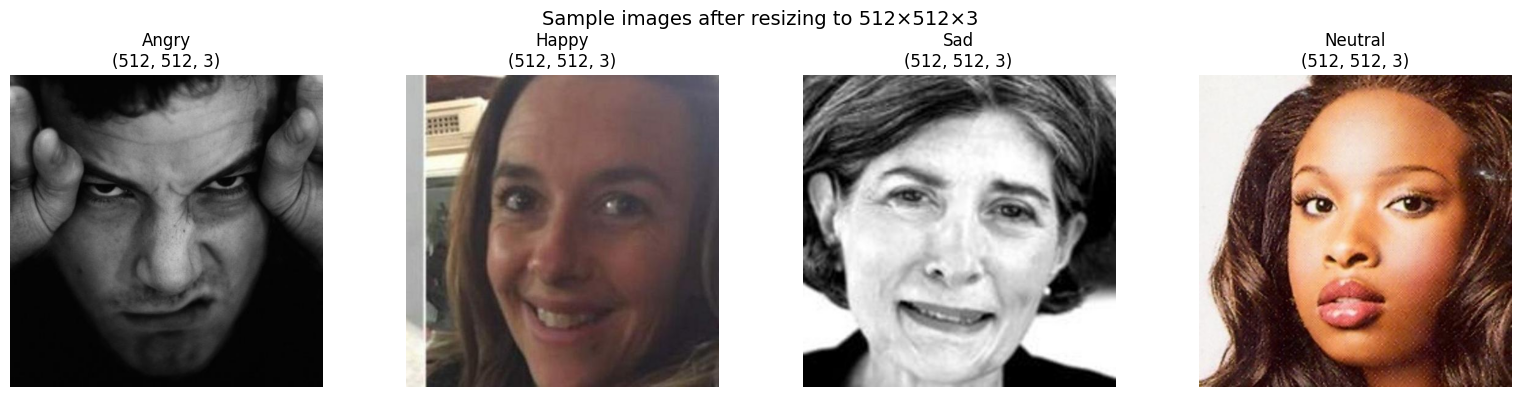

In [2]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Display one sample per class from the training split
fig, axes = plt.subplots(1, len(CLASSES), figsize=(16, 4))
fig.suptitle("Sample images after resizing to 512×512×3", fontsize=14)

for ax, cls in zip(axes, CLASSES):
    cls_train_dir = OUTPUT_DIR / "train" / cls
    sample = next(cls_train_dir.iterdir())   # pick first image
    img = mpimg.imread(sample)
    ax.imshow(img)
    ax.set_title(f"{cls}\n{img.shape}")
    ax.axis("off")

plt.tight_layout()
plt.show()

---
# First Model (35%) – CNN from Scratch

We build a full convolutional feature extractor **from scratch using only NumPy** (no deep learning libraries).  
The extracted features are then fed to **K-Means** for unsupervised clustering.

Architecture overview:
```
Input (512×512×3)
  └── ConvBlock 1: ConvLayer → PoolingLayer → ReLU  →  (255×255×5)
  └── ConvBlock 2: ConvLayer → PoolingLayer → ReLU  →  (126×126×5)
  └── ConvBlock 3: ConvLayer → PoolingLayer → ReLU  →  ( 62× 62×5)
  └── Flatten                                        →  (19220,)
  └── Linear downsample                             →  (128,)
  └── K-Means clustering                            →  class label
```

## Step 1 – ConvLayer (10%)

### What does convolution do?
A filter (kernel) slides over the input image one position at a time.  
At each position it **element-wise multiplies** the kernel with the overlapping patch and **sums** the result → one number.  
Repeating this across the whole image produces a **feature map**.  
With 5 filters we get 5 feature maps stacked → output shape `(H-2, W-2, 5)` for a 3×3 kernel with no padding.

### Two initialization methods
| Method | When to use |
|--------|-------------|
| `ConvLayer.random(num_filters, filter_size)` | Create random filter weights |
| `ConvLayer(filter_weights)` | Pass a pre-defined 3-D weight array |

### The 5 predefined filters and what they detect
| Filter | Name | Detects |
|--------|------|---------|
| (a) all-ones | Box / Average | General brightness, blurs image |
| (b) identity | Identity | Passes image unchanged |
| (c) Sobel-X | Horizontal gradient | **Vertical edges** |
| (d) Sobel-Y | Vertical gradient | **Horizontal edges** |
| (e) Laplacian | Sharpening | **All edges / fine details** |

### Efficiency note
Instead of three nested Python loops (very slow on 512×512 images),  
we use `numpy.lib.stride_tricks.sliding_window_view` to extract all patches at once  
and `np.einsum` to multiply-and-sum in a single vectorized call.

In [3]:
import numpy as np

class ConvLayer:
    """
    A single convolutional layer implemented from scratch with NumPy.

    Each filter is applied to every input channel independently;
    the results are summed across channels to produce one feature map per filter.
    This is standard cross-correlation (no padding, stride = 1).

    Two ways to create a ConvLayer
    ─────────────────────────────
    1) Random weights:
           layer = ConvLayer.random(num_filters=5, filter_size=3)

    2) Pre-defined weights (3-D array of shape [num_filters, h, w]):
           layer = ConvLayer(my_filter_array)
    """

    # ── Initialization method 2: from a pre-defined weight matrix ─────────────
    def __init__(self, filter_weights):
        """
        Parameters
        ----------
        filter_weights : array-like, shape (num_filters, filter_h, filter_w)
        """
        self.filters = np.array(filter_weights, dtype=np.float64)  # (F, kH, kW)
        self.num_filters, self.filter_h, self.filter_w = self.filters.shape

    # ── Initialization method 1: random weights ────────────────────────────────
    @classmethod
    def random(cls, num_filters, filter_size):
        """
        Parameters
        ----------
        num_filters : int   number of filters
        filter_size : int   spatial size (filter_size × filter_size)
        """
        weights = np.random.randn(num_filters, filter_size, filter_size)
        return cls(weights)

    # ── Internal helper: convolve a single 2-D channel with a single kernel ────
    @staticmethod
    def _convolve2d(channel, kernel):
        """
        2-D valid cross-correlation using explicit for loops.

        For each valid position (i, j) in the output:
          - Extract the patch of the same size as the kernel
          - Multiply element-wise with the kernel
          - Sum all values → one output value

        Output shape: (H - kH + 1,  W - kW + 1)
        """
        H, W      = channel.shape
        kH, kW    = kernel.shape
        out_H     = H - kH + 1
        out_W     = W - kW + 1
        output    = np.zeros((out_H, out_W))

        for i in range(out_H):
            for j in range(out_W):
                # Extract the patch and compute dot product with kernel
                patch         = channel[i:i+kH, j:j+kW]   # shape (kH, kW)
                output[i, j]  = np.sum(patch * kernel)

        return output

    # ── Iterate filters over the entire input (called inside forward) ──────────
    def iterate_filters(self, x):
        """
        Slide every filter over every channel of x and collect feature maps.

        Parameters
        ----------
        x : ndarray, shape (H, W, C)

        Returns
        -------
        output : ndarray, shape (H - kH + 1, W - kW + 1, num_filters)
        """
        H, W, C = x.shape
        out_H = H - self.filter_h + 1
        out_W = W - self.filter_w + 1
        output = np.zeros((out_H, out_W, self.num_filters))

        for f_idx, kernel in enumerate(self.filters):
            # Apply the same 2-D kernel to each channel and accumulate
            feature_map = np.zeros((out_H, out_W))
            for c in range(C):
                feature_map += self._convolve2d(x[:, :, c], kernel)
            output[:, :, f_idx] = feature_map

        return output

    # ── Forward pass ───────────────────────────────────────────────────────────
    def forward(self, x):
        """
        Run a full forward pass through this convolutional layer.

        Parameters
        ----------
        x : ndarray, shape (H, W, C)   input image or feature map

        Returns
        -------
        ndarray, shape (H - kH + 1, W - kW + 1, num_filters)
        """
        return self.iterate_filters(x)


# ── Define the 5 predefined 3×3 filters from the assignment ───────────────────
PREDEFINED_FILTERS = np.array([
    # (a) Box filter – averages/blurs the image
    [[ 1,  1,  1],
     [ 1,  1,  1],
     [ 1,  1,  1]],

    # (b) Identity – passes the image unchanged
    [[ 0,  0,  0],
     [ 0,  1,  0],
     [ 0,  0,  0]],

    # (c) Sobel-X – detects vertical edges (horizontal gradient)
    [[-1,  0,  1],
     [-2,  0,  2],
     [-1,  0,  1]],

    # (d) Sobel-Y – detects horizontal edges (vertical gradient)
    [[-1, -2, -1],
     [ 0,  0,  0],
     [ 1,  2,  1]],

    # (e) Sharpening / Laplacian – enhances all edges and fine details
    [[ 0, -1,  0],
     [-1,  5, -1],
     [ 0, -1,  0]],
], dtype=np.float64)  # shape: (5, 3, 3)


## Step 2 – PoolingLayer (5%)

### What does pooling do?
After convolution the feature maps are still large (e.g. 510×510).  
Pooling **shrinks** them by scanning a small window (default **2×2**) across the map and replacing each window with a **single value**:

| Type | Formula | Effect |
|------|---------|--------|
| **MAX** | take the largest value in the window | keeps the strongest activation — most common |
| **AVERAGE** | take the mean of all values | smoother output |

- Stride = pool size → windows are **non-overlapping**
- No weights, no learning — purely structural
- 510×510 with a 2×2 pool → **255×255** (halved in both dimensions)
- Applied independently to each feature map (each of the 5 channels)

In [4]:
class PoolingLayer:
    """
    Pooling layer implemented from scratch with NumPy.

    Slides a (pool_size × pool_size) window over each channel of the input
    with stride = pool_size (non-overlapping windows) and reduces each window
    to a single value using either MAX or AVERAGE.

    Usage
    -----
    pool = PoolingLayer()                        # 2×2 MAX (defaults)
    pool = PoolingLayer(pool_size=2, pool_type='AVERAGE')
    output = pool.forward(x)                     # x shape: (H, W, C)
    """

    def __init__(self, pool_size=2, pool_type='MAX'):
        """
        Parameters
        ----------
        pool_size : int     side length of the square pooling window (default 2)
        pool_type : str     'MAX' or 'AVERAGE' (default 'MAX')
        """
        assert pool_type in ('MAX', 'AVERAGE'), "pool_type must be 'MAX' or 'AVERAGE'"
        self.pool_size = pool_size
        self.pool_type = pool_type

    # ── Iterate the pooling window over one feature map (single channel) ───────
    def _pool_channel(self, channel):
        """
        Apply pooling to a single 2-D feature map using explicit for loops.

        The window moves by pool_size each step (stride = pool_size),
        so windows never overlap.  Any incomplete border rows/columns are ignored
        (equivalent to 'valid' mode).

        Parameters
        ----------
        channel : ndarray, shape (H, W)

        Returns
        -------
        ndarray, shape (H // pool_size, W // pool_size)
        """
        H, W   = channel.shape
        p      = self.pool_size
        out_H  = H // p
        out_W  = W // p
        output = np.zeros((out_H, out_W))

        for i in range(out_H):
            for j in range(out_W):
                # Extract the current pool window
                window = channel[i*p : i*p+p,
                                 j*p : j*p+p]   # shape (p, p)

                if self.pool_type == 'MAX':
                    output[i, j] = np.max(window)
                else:                            # AVERAGE
                    output[i, j] = np.mean(window)

        return output

    # ── Iterate over all channels (called inside forward) ──────────────────────
    def iterate_filters(self, x):
        """
        Apply pooling independently to every channel of the input.

        Parameters
        ----------
        x : ndarray, shape (H, W, C)

        Returns
        -------
        ndarray, shape (H // pool_size, W // pool_size, C)
        """
        H, W, C = x.shape
        out_H   = H // self.pool_size
        out_W   = W // self.pool_size
        output  = np.zeros((out_H, out_W, C))

        for c in range(C):
            output[:, :, c] = self._pool_channel(x[:, :, c])

        return output

    # ── Forward pass ───────────────────────────────────────────────────────────
    def forward(self, x):
        """
        Run a full forward pass through this pooling layer.

        Parameters
        ----------
        x : ndarray, shape (H, W, C)

        Returns
        -------
        ndarray, shape (H // pool_size, W // pool_size, C)
        """
        return self.iterate_filters(x)


## Step 3 – Activation Function (2%)

The assignment defines the activation function as:

$$\sigma(z) = \begin{cases} z & z \geq 0 \\ 0 & \text{otherwise} \end{cases}$$

This is **ReLU** (Rectified Linear Unit). It:
- Keeps all **positive** values unchanged
- Sets all **negative** values to **zero**

**Why do we need it?**  
Convolution and pooling are both linear operations. Without an activation function, stacking multiple layers is mathematically equivalent to just one layer. ReLU introduces **non-linearity**, allowing the network to learn complex patterns.

Applied element-wise to the entire feature map — shape stays the same.

In [5]:
def relu(z):
    return np.maximum(0, z)


## Step 4 – Full Network: 3 ConvBlocks + Flatten + Downsample (8%)

### Architecture

Each **ConvBlock** = `ConvLayer → PoolingLayer → ReLU`

```
Input  (512 × 512 × 3)
  │
  ├── ConvBlock 1 ──────────────────────────────────────────────
  │     ConvLayer  (5 filters, 3×3)  →  (510, 510, 5)
  │     PoolingLayer (2×2 MAX)        →  (255, 255, 5)
  │     ReLU                          →  (255, 255, 5)
  │
  ├── ConvBlock 2 ──────────────────────────────────────────────
  │     ConvLayer  (5 filters, 3×3)  →  (253, 253, 5)
  │     PoolingLayer (2×2 MAX)        →  (126, 126, 5)
  │     ReLU                          →  (126, 126, 5)
  │
  ├── ConvBlock 3 ──────────────────────────────────────────────
  │     ConvLayer  (5 filters, 3×3)  →  (124, 124, 5)
  │     PoolingLayer (2×2 MAX)        →  ( 62,  62, 5)
  │     ReLU                          →  ( 62,  62, 5)
  │
  ├── Flatten  →  (19220,)        [62 × 62 × 5 = 19220]
  │
  └── Linear Downsample  W(19220 × 128)  →  (128,)   ← feature vector
```

### Downsample to 128
A fixed random weight matrix **W** of shape **(19220 × 128)** is used.  
`feature = flatten @ W` — this is a single matrix multiplication, projecting the 19220-dim vector down to 128 dimensions.  
These 128 values are the **feature vector** for one image, fed to K-Means.

In [6]:
class CNNFromScratch:
    """
    Feature extractor built from scratch using only NumPy.

    Architecture:
        ConvBlock 1  →  ConvBlock 2  →  ConvBlock 3
        →  Flatten  →  Downsample to 128 (average pooling over groups)

    Each ConvBlock = ConvLayer → PoolingLayer → ReLU.
    The same 5 predefined filters are reused in every ConvLayer.
    Downsampling splits the flat vector into 128 equal groups and averages each.
    """

    def __init__(self, filters, pool_size=2, pool_type='MAX', feature_dim=128):
        """
        Parameters
        ----------
        filters    : ndarray (num_filters, kH, kW)  predefined filter weights
        pool_size  : int     pooling window size (default 2)
        pool_type  : str     'MAX' or 'AVERAGE' (default 'MAX')
        feature_dim: int     output feature vector size (default 128)
        """
        # ── 3 ConvBlocks ───────────────────────────────────────────────────────
        self.conv1 = ConvLayer(filters)
        self.conv2 = ConvLayer(filters)
        self.conv3 = ConvLayer(filters)

        self.pool1 = PoolingLayer(pool_size, pool_type)
        self.pool2 = PoolingLayer(pool_size, pool_type)
        self.pool3 = PoolingLayer(pool_size, pool_type)

        self.feature_dim = feature_dim

    # ── Single ConvBlock: Conv → Pool → ReLU ───────────────────────────────────
    def _conv_block(self, x, conv, pool):
        x = conv.forward(x)   # convolution
        x = pool.forward(x)   # pooling
        x = relu(x)           # activation
        return x

    # ── Downsample flat vector to feature_dim by average pooling ───────────────
    def _downsample(self, flat, target_size):
        """
        Split the flat vector into target_size equal groups,
        return the mean of each group.

        e.g. flat shape (19220,) → split into 128 groups of ~150 values each
             → take mean of each group → output shape (128,)

        Parameters
        ----------
        flat        : ndarray, shape (N,)
        target_size : int   number of output values (128)

        Returns
        -------
        ndarray, shape (target_size,)
        """
        N      = len(flat)
        # Trim flat so it divides evenly into target_size groups
        trim   = N - (N % target_size)        # drop the last few values if needed
        flat   = flat[:trim]
        # Reshape into (target_size, group_size) then average each row
        groups = flat.reshape(target_size, -1) # (128, group_size)
        return groups.mean(axis=1)             # (128,)

    # ── Forward pass ───────────────────────────────────────────────────────────
    def forward(self, x):
        """
        Extract a 128-dim feature vector from one image.

        Parameters
        ----------
        x : ndarray, shape (H, W, C)   — normalised image (values 0–1)

        Returns
        -------
        feature : ndarray, shape (128,)
        """
        # ── 3 ConvBlocks ───────────────────────────────────────────────────────
        x = self._conv_block(x, self.conv1, self.pool1)  # (255, 255, 5)
        x = self._conv_block(x, self.conv2, self.pool2)  # (126, 126, 5)
        x = self._conv_block(x, self.conv3, self.pool3)  # ( 62,  62, 5)

        # ── Flatten ────────────────────────────────────────────────────────────
        flat = x.flatten()                               # (19220,)

        # ── Downsample: 19220 → 128 via group averaging ────────────────────────
        feature = self._downsample(flat, self.feature_dim)  # (128,)

        return feature

    # ── Run on a list of image paths ───────────────────────────────────────────
    def extract_features(self, image_paths):
        """
        Run the full network on a list of image paths.

        Parameters
        ----------
        image_paths : list of Path objects

        Returns
        -------
        features : ndarray, shape (N, 128)
        labels   : list of str  — class name for each image (folder name)
        """
        features = []
        labels   = []

        for idx, path in enumerate(image_paths):
            img  = np.array(Image.open(path).convert('RGB'), dtype=np.float64) / 255.0
            feat = self.forward(img)
            features.append(feat)
            labels.append(path.parent.name)

            if (idx + 1) % 10 == 0:
                print(f"  Processed {idx + 1} / {len(image_paths)}")

        return np.array(features), labels



## Step 5 – K-Means Clustering (2%)

### What is K-Means?
K-Means groups N feature vectors into K clusters **without using labels** (unsupervised).

**Algorithm:**
1. Pick K random points from the data as initial **centroids**
2. **Assign** each point to the nearest centroid (Euclidean distance)
3. **Update** each centroid to be the mean of all points assigned to it
4. Repeat steps 2–3 until centroids stop moving (convergence)

We use **K = 4** (one cluster per emotion class).

### Flow
```
10 images × 4 classes = 40 images
       ↓  cnn.extract_features()
feature matrix  (40, 128)
       ↓  KMeans(k=4)
cluster labels  (40,)   ← 0,1,2,3
       ↓  compare with true labels
accuracy
```

In [7]:

# ──────────────────────────────────────────────────────────────────────────────
# K-Means Clustering — implemented from scratch using only NumPy
# Input : features  — ndarray of shape (N, 128), the output of cnn.extract_features()
#                     Each row is one image's 128-dimensional feature vector.
# Output: cluster_assignments — ndarray of shape (N,), cluster index (0-3) per image
#         cluster_vectors     — list of 4 lists, each holding the feature vectors
#                               assigned to that cluster
# ──────────────────────────────────────────────────────────────────────────────



# ══════════════════════════════════════════════════════════════════════════════
# Step 5a – Helper: Euclidean distance between one vector and many centroids
# ══════════════════════════════════════════════════════════════════════════════
def euclidean_distances(vector, centroids):
    """
    Compute the Euclidean distance from a single feature vector to every centroid.

    The Euclidean distance between two vectors a and b of length D is:
        dist(a, b) = sqrt( sum_d (a_d - b_d)^2 )

    Parameters
    ----------
    vector    : ndarray, shape (D,)       — one feature vector
    centroids : ndarray, shape (K, D)     — all K centroid positions

    Returns
    -------
    distances : ndarray, shape (K,)       — distance to each centroid
    """
    # Subtract the vector from every centroid row → (K, D) difference matrix
    diff = centroids - vector          # broadcasting: (K, D) - (D,) → (K, D)

    # Square every element, sum across the feature dimension (axis=1), take sqrt
    distances = np.sqrt(np.sum(diff ** 2, axis=1))   # shape (K,)

    return distances


# ══════════════════════════════════════════════════════════════════════════════
# Step 5b – Helper: Assign every feature vector to its nearest centroid
# ══════════════════════════════════════════════════════════════════════════════
def assign_clusters(features, centroids):
    """
    For each feature vector, find the index of the closest centroid.
    Also build a list-of-lists so each cluster stores the vectors assigned to it.

    Parameters
    ----------
    features  : ndarray, shape (N, D)   — all feature vectors
    centroids : ndarray, shape (K, D)   — current centroid positions

    Returns
    -------
    assignments    : ndarray, shape (N,)   — cluster index (0 … K-1) per vector
    cluster_vectors: list of K lists       — each sub-list holds the feature vectors
                                             (ndarray, shape (D,)) assigned to that cluster
    """
    K = len(centroids)
    N = len(features)

    assignments     = np.zeros(N, dtype=int)          # one cluster label per image
    cluster_vectors = [[] for _ in range(K)]          # K empty lists, one per cluster

    for i, vec in enumerate(features):
        # Compute distance from this vector to all K centroids
        dists = euclidean_distances(vec, centroids)   # shape (K,)

        # The cluster with the smallest distance "wins"
        closest = int(np.argmin(dists))               # scalar index 0 … K-1

        # Record the assignment
        assignments[i] = closest

        # Store the feature vector in the matching cluster's list
        cluster_vectors[closest].append(vec)

    return assignments, cluster_vectors


# ══════════════════════════════════════════════════════════════════════════════
# Step 5c – Helper: Recompute centroids as the mean of each cluster's vectors
# ══════════════════════════════════════════════════════════════════════════════
def update_centroids(cluster_vectors, D, old_centroids):
    """
    Each centroid moves to the mean position of all vectors in its cluster.
    If a cluster is empty (no vectors were assigned to it), keep the old centroid
    in place to avoid a NaN centroid.

    Parameters
    ----------
    cluster_vectors : list of K lists     — feature vectors per cluster
    D               : int                 — feature dimension (128)
    old_centroids   : ndarray, shape(K,D) — previous centroid positions (fallback)

    Returns
    -------
    new_centroids : ndarray, shape (K, D)
    """
    K = len(cluster_vectors)
    new_centroids = np.zeros((K, D))

    for k, vectors in enumerate(cluster_vectors):
        if len(vectors) == 0:
            # Empty cluster — keep the old centroid to avoid collapse
            new_centroids[k] = old_centroids[k]
        else:
            # Stack the assigned vectors into a matrix and take the column-wise mean
            # e.g. if cluster k has 12 vectors of shape (128,):
            #   stack → (12, 128)   .mean(axis=0) → (128,)
            new_centroids[k] = np.mean(np.array(vectors), axis=0)

    return new_centroids


# ══════════════════════════════════════════════════════════════════════════════
# Step 5d – Main K-Means function
# ══════════════════════════════════════════════════════════════════════════════
def kmeans(features, k=4, max_iters=100, tol=1e-4, seed=42):
    """
    K-Means clustering implemented from scratch.

    Algorithm
    ---------
    1. Randomly pick K feature vectors from the data as initial centroids.
    2. ASSIGN  – assign every point to its nearest centroid (Euclidean distance).
    3. UPDATE  – move each centroid to the mean of its assigned points.
    4. REPEAT steps 2–3 until the centroids move less than `tol` OR `max_iters`
       iterations are reached.

    Parameters
    ----------
    features  : ndarray, shape (N, D)   — feature matrix from the CNN
    k         : int                     — number of clusters (default 4)
    max_iters : int                     — iteration cap (default 100)
    tol       : float                   — convergence threshold on centroid shift
    seed      : int                     — random seed for reproducible init

    Returns
    -------
    assignments    : ndarray, shape (N,)   — cluster label (0 … k-1) per image
    centroids      : ndarray, shape (k, D) — final centroid positions
    cluster_vectors: list of k lists       — feature vectors assigned to each cluster
    history        : list of float         — total centroid shift per iteration
    """

    np.random.seed(seed)
    N, D = features.shape

    # ── Step 1: Initialisation ─────────────────────────────────────────────────
    # Choose K distinct indices at random from the N available feature vectors.
    init_indices = np.random.choice(N, size=k, replace=False)
    centroids    = features[init_indices].copy()   # shape (K, D)

    print(f"K-Means initialised with K={k}")
    print(f"  Feature matrix shape : {features.shape}")
    print(f"  Initial centroid rows: {init_indices.tolist()}")
    print(f"  Centroid shape       : {centroids.shape}")
    print()

    history = []   # track total centroid displacement per iteration

    # ── Steps 2–4: Iterate ────────────────────────────────────────────────────
    for iteration in range(1, max_iters + 1):

        # ── Step 2: Assignment ────────────────────────────────────────────────
        # Each feature vector is assigned to the cluster whose centroid is closest.
        # cluster_vectors[k] holds a Python list of all (D,) arrays in cluster k.
        assignments, cluster_vectors = assign_clusters(features, centroids)

        # ── Step 3: Update ────────────────────────────────────────────────────
        # Each centroid moves to the mean of all vectors assigned to its cluster.
        new_centroids = update_centroids(cluster_vectors, D, centroids)

        # ── Convergence check ─────────────────────────────────────────────────
        # Measure how far the centroids moved this iteration.
        # Total shift = sum of Euclidean norms across all K centroids.
        shift = np.sum(np.sqrt(np.sum((new_centroids - centroids) ** 2, axis=1)))
        history.append(shift)

        # Print progress every 10 iterations (and always on the first)
        if iteration == 1 or iteration % 10 == 0:
            cluster_sizes = [len(cv) for cv in cluster_vectors]
            print(f"  Iteration {iteration:>3d} | centroid shift: {shift:.6f} | "
                  f"cluster sizes: {cluster_sizes}")

        # Accept the new centroids for the next round
        centroids = new_centroids

        # Stop early if centroids have effectively stopped moving
        if shift < tol:
            print(f"\n  Converged at iteration {iteration}  (shift={shift:.2e} < tol={tol})")
            break

    else:
        print(f"\n  Reached max_iters={max_iters} without full convergence.")

    return assignments, centroids, cluster_vectors, history


In [8]:

# ══════════════════════════════════════════════════════════════════════════════
# get_cluster_labels
#
# For each cluster, every stored feature vector is looked up by index in the
# original `features` array (the one returned by extract_features).
# Because true_labels[i] is synced with features[i], the index gives us
# the ground-truth label for that vector.
#
# Parameters
# ----------
# cluster_vectors : list of K lists  — output of kmeans(); each sub-list holds
#                                      the (128,) feature vectors assigned to
#                                      that cluster
# features        : ndarray (N, 128) — the full feature matrix from extract_features()
# true_labels     : list of N str    — ground-truth class names, synced with features
#                                      (true_labels[i] is the label for features[i])
#
# Returns
# -------
# dominant_label_map : dict  { cluster_idx  →  str }
#                      The most frequent true label in each cluster.
#
# label_count_map    : dict  { cluster_idx  →  {label: count} }
#                      How many times each label appears in each cluster.
# ══════════════════════════════════════════════════════════════════════════════

def get_cluster_labels(cluster_vectors, features, true_labels):

    dominant_label_map = {}   # cluster 0 → "Happy", cluster 1 → "Sad", …
    label_count_map    = {}   # cluster 0 → {"Happy": 7, "Angry": 3}, …

    # ── Loop over each cluster ────────────────────────────────────────────────
    for cluster_idx, vectors in enumerate(cluster_vectors):

        label_counts = {}   # running tally of labels seen in this cluster

        # ── Loop over every feature vector stored in this cluster ─────────────
        for vec in vectors:

            # Find which row in the full features array this vector came from.
            # np.all(..., axis=1) checks element-wise equality across the 128
            # feature dimensions for every row, giving a boolean mask of shape (N,).
            # np.where returns the row indices where the mask is True.
            matches = np.where(np.all(features == vec, axis=1))[0]

            # Take the first match (there should be exactly one unless two images
            # produced bit-for-bit identical feature vectors)
            original_idx = matches[0]

            # Map the index to its ground-truth label
            label = true_labels[original_idx]

            # Accumulate the count for this label inside the current cluster
            if label in label_counts:
                label_counts[label] += 1
            else:
                label_counts[label] = 1

        # ── Dominant label = the label with the highest count ─────────────────
        dominant = max(label_counts, key=label_counts.get)

        dominant_label_map[cluster_idx] = dominant
        label_count_map[cluster_idx]    = label_counts

    return dominant_label_map, label_count_map




In [9]:

# ══════════════════════════════════════════════════════════════════════════════
# train_pipeline
#
# Orchestrates the entire training sequence in one call:
#
#   train images  →  CNN  →  features (N, 128)
#                         →  K-Means  →  cluster assignments + centroids
#                                     →  get_cluster_labels
#                                     →  dominant_label_map + label_count_map
#
# Parameters
# ----------
# train_dir : Path   root of the training split, e.g. OUTPUT_DIR / "train"
#                    expected layout: train_dir / ClassName / image.jpg
# cnn       : CNNFromScratch  — already-built feature extractor
# k         : int    number of K-Means clusters (default 4)
# max_iters : int    K-Means iteration cap      (default 100)
# tol       : float  K-Means convergence threshold (default 1e-4)
# seed      : int    random seed for K-Means init  (default SEED)
#
# Returns
# -------
# features          : ndarray (N, 128)  — one row per training image
# true_labels       : list of N str     — ground-truth class per image
# assignments       : ndarray (N,)      — K-Means cluster index per image
# final_centroids   : ndarray (K, 128)  — converged centroid positions
# cluster_vectors   : list of K lists   — feature vectors grouped by cluster
# dominant_label_map: dict {cluster_idx → str}   — majority label per cluster
# label_count_map   : dict {cluster_idx → {label: count}}
# ══════════════════════════════════════════════════════════════════════════════

def train_pipeline(cnn, train_dir = OUTPUT_DIR / "train" , k=4, max_iters=100, tol=1e-4, seed=SEED):

    train_dir = Path(train_dir)

    # ── Step 1: collect all training image paths ──────────────────────────────
    all_paths = sorted([
        p
        for cls_dir in train_dir.iterdir() if cls_dir.is_dir()
        for p in cls_dir.iterdir()
        if p.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp"}
    ])

    print("=" * 60)
    print("TRAIN PIPELINE")
    print("=" * 60)
    print(f"Step 1 — Found {len(all_paths)} training images in '{train_dir}'")

    # ── Step 2: extract CNN features for every training image ─────────────────
    # cnn.extract_features() passes each image through the 3 ConvBlocks and
    # returns a (N, 128) feature matrix and the synced list of class labels.
    print(f"\nStep 2 — Extracting CNN features  ({len(all_paths)} images × 128 dims)")
    features, true_labels = cnn.extract_features(all_paths)
    print(f"  features shape : {features.shape}")
    print(f"  labels sample  : {true_labels[:4]}")

    # ── Step 3: run K-Means on the extracted features ─────────────────────────
    # kmeans() returns the final centroid positions and cluster_vectors —
    # a list of K lists where each sub-list holds the (128,) feature vectors
    # assigned to that cluster.
    print(f"\nStep 3 — Running K-Means  (K={k}, max_iters={max_iters})")
    assignments, final_centroids, cluster_vectors, history = kmeans(
        features,
        k         = k,
        max_iters = max_iters,
        tol       = tol,
        seed      = seed,
    )

    # ── Step 4: label each cluster using the ground-truth labels ──────────────
    # get_cluster_labels looks up each stored feature vector in the features
    # array, finds its index, and maps it to the synced true_labels list.
    # This gives us: which emotion does each cluster number represent.
    print(f"\nStep 4 — Labelling clusters via get_cluster_labels")
    dominant_label_map, label_count_map = get_cluster_labels(
        cluster_vectors, features, true_labels
    )

    # Print a clean summary of what each cluster was assigned
    print("\n  Cluster label summary:")
    for cluster_idx in sorted(dominant_label_map):
        dominant = dominant_label_map[cluster_idx]
        counts   = label_count_map[cluster_idx]
        print(f"    Cluster {cluster_idx}  →  dominant: {dominant:<10}  counts: {counts}")

    print("\nTraining pipeline complete.")
    print("=" * 60)

    return (
        features,
        true_labels,
        assignments,
        final_centroids,
        cluster_vectors,
        dominant_label_map,
        label_count_map,
    )





In [10]:
cnn = CNNFromScratch(filters=PREDEFINED_FILTERS, pool_size=2, pool_type='MAX', feature_dim=128)
features, true_labels, assignments, final_centroids, cluster_vectors, dominant_label_map, label_count_map = train_pipeline(cnn)

TRAIN PIPELINE
Step 1 — Found 28 training images in 'Dataset/processed/train'

Step 2 — Extracting CNN features  (28 images × 128 dims)
  Processed 10 / 28
  Processed 20 / 28
  features shape : (28, 128)
  labels sample  : ['Angry', 'Angry', 'Angry', 'Angry']

Step 3 — Running K-Means  (K=4, max_iters=100)
K-Means initialised with K=4
  Feature matrix shape : (28, 128)
  Initial centroid rows: [9, 25, 8, 21]
  Centroid shape       : (4, 128)

  Iteration   1 | centroid shift: 4026.434791 | cluster sizes: [9, 4, 5, 10]

  Converged at iteration 5  (shift=0.00e+00 < tol=0.0001)

Step 4 — Labelling clusters via get_cluster_labels

  Cluster label summary:
    Cluster 0  →  dominant: Angry       counts: {'Angry': 3, 'Happy': 1, 'Neutral': 2}
    Cluster 1  →  dominant: Sad         counts: {'Angry': 2, 'Happy': 2, 'Neutral': 2, 'Sad': 4}
    Cluster 2  →  dominant: Angry       counts: {'Angry': 1, 'Happy': 1, 'Sad': 1}
    Cluster 3  →  dominant: Happy       counts: {'Angry': 1, 'Happy': 3

In [11]:

# ══════════════════════════════════════════════════════════════════════════════
# predict_test_images
#
# Runs the full prediction pipeline on every image in the test directory:
#   image file  →  CNN feature vector  →  nearest cluster  →  class label
#
# Parameters
# ----------
# test_dir          : Path   root of the test split, e.g. OUTPUT_DIR / "test"
#                            expected layout: test_dir / ClassName / image.jpg
# cnn               : CNNFromScratch  — already-built feature extractor
# final_centroids   : ndarray (K, D)  — centroid positions from kmeans()
# dominant_label_map: dict {cluster_idx → label}  — from get_cluster_labels()
#
# Returns
# -------
# results : list of dicts, one per image, each containing:
#     {
#       "image"      : str   — filename
#       "true_label" : str   — ground-truth class (taken from the folder name)
#       "cluster"    : int   — K-Means cluster assignment (0 … K-1)
#       "pred_label" : str   — label mapped from that cluster
#     }
# ══════════════════════════════════════════════════════════════════════════════

def predict_test_images(test_dir, cnn, final_centroids, dominant_label_map):

    results = []

    # ── Step 1: collect all test image paths across every class folder ────────
    test_dir  = Path(test_dir)
    all_paths = sorted([
        p
        for cls_dir in test_dir.iterdir() if cls_dir.is_dir()
        for p in cls_dir.iterdir()
        if p.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp"}
    ])

    print(f"Found {len(all_paths)} test images in '{test_dir}'")
    print("-" * 60)

    for img_path in all_paths:

        # ── Step 2: extract feature vector via CNN ────────────────────────────
        # Load, convert to RGB float [0,1], run through the 3 ConvBlocks
        img     = np.array(Image.open(img_path).convert("RGB"), dtype=np.float64) / 255.0
        feature = cnn.forward(img)   # shape (128,)

        # ── Step 3: assign to nearest cluster ────────────────────────────────
        # Reuse euclidean_distances to get distance from this vector to every
        # centroid, then pick the closest one with argmin.
        distances   = euclidean_distances(feature, final_centroids)  # shape (K,)
        cluster_idx = int(np.argmin(distances))                       # scalar 0…K-1

        # ── Step 4: map cluster index → class label ───────────────────────────
        # dominant_label_map tells us which emotion K-Means associates with
        # each cluster (built from the training features by get_cluster_labels).
        pred_label = dominant_label_map[cluster_idx]

        # Ground-truth label is the name of the parent folder
        true_label = img_path.parent.name

        results.append({
            "image"      : img_path.name,
            "true_label" : true_label,
            "cluster"    : cluster_idx,
            "pred_label" : pred_label,
        })

        print(f"  {img_path.name:<30}  true: {true_label:<10}  "
              f"cluster: {cluster_idx}  pred: {pred_label}")

    return results

In [12]:
results  = predict_test_images(OUTPUT_DIR / "test", cnn, final_centroids, dominant_label_map)

Found 4 test images in 'Dataset/processed/test'
------------------------------------------------------------
  Angry_869.jpg                   true: Angry       cluster: 0  pred: Angry
  Happy_936.jpg                   true: Happy       cluster: 2  pred: Angry
  Neutral_2490.jpg                true: Neutral     cluster: 0  pred: Angry
  Sad_1033.jpg                    true: Sad         cluster: 1  pred: Sad
